# PANAGEA exploration 4 — Inherent optical properties (IOPs)

The `iop` table carries phytoplankton absorption (`aph`), CDOM + detrital
absorption (`acdom`), particulate backscatter (`bbp`), diffuse attenuation
(`kd`) and total suspended matter. Here we look at data availability, the
aph-chlorophyll relationship, and the CDOM spectral slope.

Findings are summarised at the bottom.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ocpy.insitu import panagea

iop = panagea.load('iop')
meta = panagea.column_metadata(iop)

def cols_for(var):
    c = [(n, m['wavelength']) for n, m in meta.items()
         if m.get('variable') == var and m.get('role') == 'spectral']
    return sorted(c, key=lambda t: t[1])

for var in ['aph', 'acdom', 'bbp', 'kd']:
    c = cols_for(var)
    rows = iop[[n for n, _ in c]].notna().any(axis=1).sum()
    print('%-6s %4d wavelengths, %5d observations with data' %
          (var, len(c), rows))

aph    2386 wavelengths,  4265 observations with data
acdom    33 wavelengths,  1654 observations with data
bbp      32 wavelengths,   792 observations with data
kd       25 wavelengths,  2454 observations with data


## Phytoplankton absorption aph(443) vs chlorophyll

aph(443) should scale with chlorophyll (more phytoplankton -> more
absorption); the Bricaud relationships are built on exactly this.

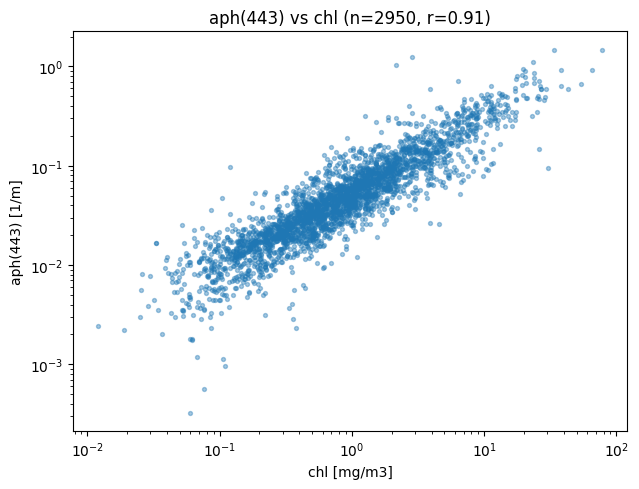

log-log correlation = 0.908


In [2]:
def nearest(var, target):
    c = cols_for(var)
    return min(c, key=lambda t: abs(t[1] - target))[0]

aph443 = iop[nearest('aph', 443)]
chla = panagea.load('chla')
chl = chla['chla_hplc'].fillna(chla['chla_fluor'])
j = pd.DataFrame({'aph443': aph443}).join(chl.rename('chl'), how='inner')
j = j.dropna()
j = j[(j['aph443'] > 0) & (j['chl'] > 0)]
r = np.corrcoef(np.log10(j['aph443']), np.log10(j['chl']))[0, 1]

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(j['chl'], j['aph443'], s=8, alpha=0.4)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('chl [mg/m3]'); ax.set_ylabel('aph(443) [1/m]')
ax.set_title('aph(443) vs chl (n=%d, r=%.2f)' % (len(j), r))
plt.tight_layout(); plt.show()
print('log-log correlation = %.3f' % r)

## CDOM + detrital absorption spectral slope

acdom typically decays exponentially with wavelength,
`acdom(lam) = acdom(ref) * exp(-S (lam - ref))`. We fit the slope S over
400-500 nm for every spectrum with enough points.

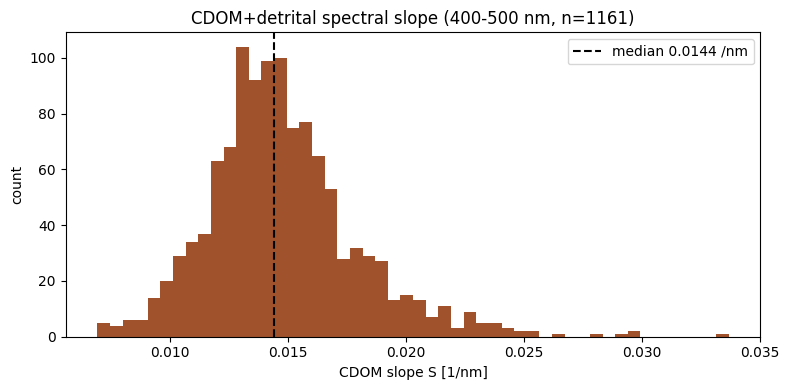

median S = 0.0144 /nm


In [3]:
c = cols_for('acdom')
wv = np.array([w for _, w in c])
A = iop[[n for n, _ in c]].to_numpy(dtype=float)
sel = (wv >= 400) & (wv <= 500)
slopes = []
for row in A:
    y, x = row[sel], wv[sel]
    good = np.isfinite(y) & (y > 0)
    if good.sum() >= 4:
        s = -np.polyfit(x[good], np.log(y[good]), 1)[0]
        if 0 < s < 0.05:  # keep physically plausible slopes
            slopes.append(s)
slopes = np.array(slopes)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(slopes, bins=50, color='sienna')
ax.axvline(np.median(slopes), color='k', ls='--',
           label='median %.4f /nm' % np.median(slopes))
ax.set_xlabel('CDOM slope S [1/nm]'); ax.set_ylabel('count')
ax.set_title('CDOM+detrital spectral slope (400-500 nm, n=%d)' %
             len(slopes))
ax.legend()
plt.tight_layout(); plt.show()
print('median S = %.4f /nm' % np.median(slopes))

## Findings — IOPs

* **IOPs are the scarce, unevenly-sampled measurements.** Of ~7.4k IOP
  observations, aph is the most complete; acdom (~1.7k), Kd (~2.5k) and
  especially bbp (~0.8k) are progressively sparser. Backscatter is the
  rarest in-situ quantity in PANAGEA.
* **aph(443) tracks chlorophyll strongly.** The log-log correlation is
  ~+0.91 — consistent with the Bricaud-type power-law relationship between
  phytoplankton absorption and chlorophyll, and a good independent check on
  the `ID` join between the IOP and chlorophyll tables.
* **CDOM slope is physically sensible.** The fitted CDOM+detrital slope over
  400-500 nm has a median near 0.014 /nm, in the canonical 0.01-0.02 /nm
  range reported in the literature, indicating the absorption spectra are
  well-formed.